In [1]:
# using existing code from https://medium.com/algorithmic-trading/advanced-high-frequency-trading-strategy-leveraging-order-book-imbalance-and-vwap-for-enhanced-74b93233b6a7
# appplying only OBI strategy

In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("./data/id9o0mbu0rvqqbuf.csv")
df.shape

(11590088, 14)

In [4]:
df.head()

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX
0,2023-05-10,3:59:00.005197350,K,0.00,0,0.00,0,L,1090,1,NaN,N,AAPL,NaN
1,2023-05-10,3:59:00.095617932,Z,0.00,0,0.00,0,L,2024,1,NaN,N,AAPL,NaN
2,2023-05-10,4:00:00.003953823,Q,171.23,4,0.00,0,R,3892,2,NaN,N,AAPL,NaN
3,2023-05-10,4:00:00.003974778,Q,171.23,4,171.44,4,R,3893,4,NaN,N,AAPL,NaN
4,2023-05-10,4:00:00.005169850,K,171.02,10,0.00,0,Y,3953,0,NaN,N,AAPL,NaN


In [5]:
df['TIME_M'] = df['TIME_M'].apply(lambda x: f"{x}.000000" if '.' not in x else x)

# Convert TIME_M to datetime with nanosecond precision and update the column type
df['TIME_PD'] = pd.to_datetime(df['TIME_M'], format='%H:%M:%S.%f', errors='coerce')


In [6]:
df.shape

(11590088, 15)

In [7]:
df.dtypes

DATE                  object
TIME_M                object
EX                    object
BID                  float64
BIDSIZ                 int64
ASK                  float64
ASKSIZ                 int64
QU_COND               object
QU_SEQNUM              int64
NATBBO_IND             int64
QU_CANCEL            float64
QU_SOURCE             object
SYM_ROOT              object
SYM_SUFFIX           float64
TIME_PD       datetime64[ns]
dtype: object

In [9]:
# Filter rows between 9:30:00 and 16:00:00
df = df[(df['TIME_PD'].dt.time >= pd.to_datetime('09:30:00.000000000').time()) &
                 (df['TIME_PD'].dt.time <= pd.to_datetime('16:00:00.000000000').time())]

del df['TIME_PD']

df.shape, df.head(5), df.tail(5)

((11517550, 14),
              DATE             TIME_M EX     BID  BIDSIZ     ASK  ASKSIZ  \
 64873  2023-05-10  9:30:00.000431616  Q  172.98       2  173.02      34   
 64874  2023-05-10  9:30:00.000735136  U  172.92       1  173.04       1   
 64875  2023-05-10  9:30:00.000890000  P  172.94      11  173.09       3   
 64876  2023-05-10  9:30:00.000916688  Q  172.98       3  173.02      34   
 64877  2023-05-10  9:30:00.000934507  P  172.94      11  173.04       1   
 
       QU_COND  QU_SEQNUM  NATBBO_IND  QU_CANCEL QU_SOURCE SYM_ROOT  SYM_SUFFIX  
 64873       R    1095038           4        NaN         N     AAPL         NaN  
 64874       R    1095065           0        NaN         N     AAPL         NaN  
 64875       R    1095078           0        NaN         N     AAPL         NaN  
 64876       R    1095080           4        NaN         N     AAPL         NaN  
 64877       R    1095083           0        NaN         N     AAPL         NaN  ,
                 DATE           

# should do some data exploration here, review some of the value counts to find cancelled orders etc

In [10]:
class NBBOTracker:
    """
    Tracks the National Best Bid and Offer (NBBO) across multiple exchanges from quote-level data.

    This class is intended to be used with high-frequency market data (e.g., TAQ) where each row 
    represents a quote update from a specific exchange at a given timestamp. It maintains the 
    current NBBO and accumulates size contributions at the best bid and ask across exchanges.

    Attributes
    ----------
    bid : float or None
        The current best bid price observed across exchanges.
    ask : float or None
        The current best ask price observed across exchanges.
    bid_sizes : dict
        Dictionary mapping exchange codes to bid sizes at the NBBO bid.
    ask_sizes : dict
        Dictionary mapping exchange codes to ask sizes at the NBBO ask.

    Methods
    -------
    update(row):
        Update NBBO state based on a new row of quote data. Adds the following columns to the row:
        - 'best_bid': the current best bid price
        - 'best_ask': the current best ask price
        - 'total_best_bid_size': cumulative bid size at NBBO bid across all exchanges
        - 'total_best_ask_size': cumulative ask size at NBBO ask across all exchanges

    Usage
    -----
    >>> tracker = NBBOTracker()
    >>> df = df.apply(tracker.update, axis=1)
    """
    def __init__(self):
        self.bid = None
        self.ask = None
        self.bid_sizes = {}
        self.ask_sizes = {}

    def update(self, row):
        exch = row['EX']
        if row['NATBBO_IND'] == 4:  # NBBO update means the national best bid and offer have changed
            self.bid = row['BID']
            self.ask = row['ASK']
            self.bid_sizes = {exch: row['BIDSIZ']} if pd.notna(row['BID']) else {}   # if no bid, no size
            self.ask_sizes = {exch: row['ASKSIZ']} if pd.notna(row['ASK']) else {}
        else:   # Otherwse means the national best bid and offer have not changed
            if pd.notna(row['BID']) and row['BID'] == self.bid: # if the bid is the same as the NBBO bid increment the size
                self.bid_sizes[exch] = row['BIDSIZ']
            if pd.notna(row['ASK']) and row['ASK'] == self.ask:
                self.ask_sizes[exch] = row['ASKSIZ']

        row['best_bid'] = self.bid
        row['best_ask'] = self.ask
        row['total_best_bid_size'] = sum(self.bid_sizes.values())
        row['total_best_ask_size'] = sum(self.ask_sizes.values())
        # print(row['total_best_bid_size'])
        return row


In [11]:
tracker = NBBOTracker()
df = df.apply(tracker.update, axis=1)

# df[['best_bid', 'best_ask', 'best_bid_size', 'best_ask_size']] = \
#     df[['best_bid', 'best_ask', 'best_bid_size', 'best_ask_size']].ffill()

# Display the updated DataFrame with new columns
df.head()

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size
64873,2023-05-10,9:30:00.000431616,Q,172.98,2,173.02,34,R,1095038,4,NaN,N,AAPL,NaN,172.98,173.02,2,34
64874,2023-05-10,9:30:00.000735136,U,172.92,1,173.04,1,R,1095065,0,NaN,N,AAPL,NaN,172.98,173.02,2,34
64875,2023-05-10,9:30:00.000890000,P,172.94,11,173.09,3,R,1095078,0,NaN,N,AAPL,NaN,172.98,173.02,2,34
64876,2023-05-10,9:30:00.000916688,Q,172.98,3,173.02,34,R,1095080,4,NaN,N,AAPL,NaN,172.98,173.02,3,34
64877,2023-05-10,9:30:00.000934507,P,172.94,11,173.04,1,R,1095083,0,NaN,N,AAPL,NaN,172.98,173.02,3,34


In [12]:
df[['total_best_bid_size', 'total_best_ask_size']].describe()

,total_best_bid_size,total_best_ask_size
count,1.151755e+07,1.151755e+07
mean,1.658739e+01,1.698212e+01
std,1.288877e+01,1.550543e+01
min,1.000000e+00,1.000000e+00
25%,7.000000e+00,7.000000e+00
50%,1.300000e+01,1.300000e+01
75%,2.300000e+01,2.300000e+01
max,3.240000e+02,7.540000e+02


### For 5 mins data in 10 May 2023
just taking a small sample, we have a max of 100 only. Would be good to see with full 24 hr dataset, what is the distribution

Lets see the sample of when size is more than 100

In [13]:
filtered_large_sizes = df[(df['total_best_bid_size'] > 100) | (df['total_best_ask_size'] > 100)]
# filtered_large_sizes.head(60)

take one episode when the size is more than 100

In [14]:
filtered_df = df.loc[181701:182001]
filtered_df

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size
181701,2023-05-10,9:33:50.568786372,H,173.84,1,173.87,3,R,2299282,2,NaN,N,AAPL,NaN,173.85,173.86,6,5
181702,2023-05-10,9:33:50.575051869,X,173.79,2,173.89,2,R,2299285,0,NaN,N,AAPL,NaN,173.85,173.86,6,5
181703,2023-05-10,9:33:50.575052995,Q,173.86,1,173.88,9,R,2299286,0,NaN,N,AAPL,NaN,173.85,173.86,6,5
181704,2023-05-10,9:33:50.575210323,Z,173.84,5,173.87,1,R,2299288,0,NaN,N,AAPL,NaN,173.85,173.86,6,5
181705,2023-05-10,9:33:50.575214617,K,173.84,1,173.88,1,R,2299289,0,NaN,N,AAPL,NaN,173.85,173.86,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181997,2023-05-10,9:33:51.666886746,Q,173.84,5,173.86,1,R,2302904,2,NaN,N,AAPL,NaN,173.84,173.86,5,1
181998,2023-05-10,9:33:51.666894317,J,173.39,1,173.90,3,R,2302905,0,NaN,N,AAPL,NaN,173.84,173.86,5,1
181999,2023-05-10,9:33:51.666902806,Q,173.84,2,173.86,1,R,2302906,2,NaN,N,AAPL,NaN,173.84,173.86,2,1
182000,2023-05-10,9:33:51.666903221,K,173.84,1,173.88,1,R,2302907,0,NaN,N,AAPL,NaN,173.84,173.86,3,1


compute the size of order book imbalance. 

In [15]:
filtered_df = filtered_df.copy()  # Create a copy to avoid the warning
filtered_df.loc[:, 'MID_PRICE'] = (filtered_df['best_bid'] + filtered_df['best_ask']) / 2
filtered_df.loc[:, 'OBI'] = (filtered_df['total_best_bid_size'] - filtered_df['total_best_ask_size']) / \
                            (filtered_df['total_best_bid_size'] + filtered_df['total_best_ask_size'])

In [16]:
from IPython.core.display import display, HTML

# Display a scrollable preview of the dataframe
html = filtered_df[['TIME_M', 'MID_PRICE', 
                    'best_bid', 
                    'total_best_bid_size', 
                    'total_best_ask_size', 
                    'best_ask', 
                    'OBI']].to_html(index=False)
scrollable_html = f'<div style="max-height: 400px; overflow-y: scroll; border: 1px solid black;">{html}</div>'
display(HTML(scrollable_html))

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_8451/3709118466.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display
  from IPython.core.display import display, HTML


TIME_M,MID_PRICE,best_bid,total_best_bid_size,total_best_ask_size,best_ask,OBI
9:33:50.568786372,173.855,173.85,6,5,173.86,0.090909
9:33:50.575051869,173.855,173.85,6,5,173.86,0.090909
9:33:50.575052995,173.855,173.85,6,5,173.86,0.090909
9:33:50.575210323,173.855,173.85,6,5,173.86,0.090909
9:33:50.575214617,173.855,173.85,6,5,173.86,0.090909
9:33:50.575347664,173.855,173.85,6,5,173.86,0.090909
9:33:50.579323859,173.855,173.85,6,5,173.86,0.090909
9:33:50.579624289,173.855,173.85,6,5,173.86,0.090909
9:33:50.579791572,173.855,173.85,6,5,173.86,0.090909
9:33:50.582058862,173.855,173.85,6,5,173.86,0.090909


observed that OBI is a decent indicator of price movement, although the price only changed minimally
1. first signal flip at 10:03:36.187286990 is only .01 px change ~.5% return
2. next signal flip at 10:03:36.227561398 is .01 px change again

size here should be in a round lot (100 shares)

# Try OBI strategy

In [17]:
class OBIVWAPStrategy:
    def __init__(self, vwap_window, obi_threshold, initial_cash=100_000):
        self.vwap_window = vwap_window
        self.obi_threshold = obi_threshold
        self.cash = initial_cash
        self.position = 0
        self.account_balance = []

    def calculate_vwap(self, data):
        data['MID_PRICE'] = (data['best_bid'] + data['best_ask']) / 2
        data['Volume'] = data['total_best_bid_size'] + data['total_best_ask_size']
        data['VWAP'] = (data['MID_PRICE'] * data['Volume']).rolling(window=self.vwap_window).sum() / data['Volume'].rolling(window=self.vwap_window).sum()
        return data

    def calculate_obi(self, data):
        data['OBI'] = (data['total_best_bid_size'] - data['total_best_ask_size']) / (data['total_best_bid_size'] + data['total_best_ask_size'])
        return data

    def generate_signals(self, data):
        data = self.calculate_vwap(data)
        data = self.calculate_obi(data)
        # data.dropna(inplace=True)
        data['Signal'] = 0
        data.loc[data['OBI'] > self.obi_threshold, 'Signal'] = 1  # Buy signal
        data.loc[data['OBI'] < -self.obi_threshold, 'Signal'] = -1  # Sell signal
        # data['Signal'][(data['OBI'] > self.obi_threshold) & (data['MID_PRICE'] < data['VWAP'])] = 1  # Buy signal
        # data['Signal'][(data['OBI'] < -self.obi_threshold) & (data['MID_PRICE'] > data['VWAP'])] = -1  # Sell signal
        return data

    def backtest(self, data):
        for index, row in data.iterrows():
            if row['Signal'] == 1 and self.cash >= row['best_ask'] * 100 and self.position <= 1:
                # Buy 100 shares
                self.position = 100
                self.cash -= row['best_ask'] * 100
            elif row['Signal'] == -1 and self.position > -1:
                # Sell 100 shares
                self.position = -100
                self.cash += row['best_bid'] * 100
            elif row['Signal'] == 0 and self.position != 0:
                # Close position
                if self.position > 0:
                    self.cash += row['best_bid'] * 100
                else:
                    self.cash -= row['best_ask'] * 100
                self.position = 0
            # Record the account balance
            self.account_balance.append(self.cash + self.position * row['MID_PRICE'])

        # Ensure account balance is aligned with the data index
        data['Account_Balance'] = pd.Series(self.account_balance, index=data.index)
        return data


In [18]:
df.head(2)

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,best_bid,best_ask,total_best_bid_size,total_best_ask_size
64873,2023-05-10,9:30:00.000431616,Q,172.98,2,173.02,34,R,1095038,4,NaN,N,AAPL,NaN,172.98,173.02,2,34
64874,2023-05-10,9:30:00.000735136,U,172.92,1,173.04,1,R,1095065,0,NaN,N,AAPL,NaN,172.98,173.02,2,34


In [19]:
df.QU_CANCEL.value_counts()

Series([], Name: count, dtype: int64)

In [20]:
vwap_window = 50
obi_threshold = 0.05

backtest_results = []



In [21]:
strategy = OBIVWAPStrategy(vwap_window, obi_threshold)
signal_data = strategy.generate_signals(df.copy())
backtest_data = strategy.backtest(signal_data)

In [22]:
signal_data.columns

Index(['DATE', 'TIME_M', 'EX', 'BID', 'BIDSIZ', 'ASK', 'ASKSIZ', 'QU_COND',
       'QU_SEQNUM', 'NATBBO_IND', 'QU_CANCEL', 'QU_SOURCE', 'SYM_ROOT',
       'SYM_SUFFIX', 'best_bid', 'best_ask', 'total_best_bid_size',
       'total_best_ask_size', 'MID_PRICE', 'Volume', 'VWAP', 'OBI', 'Signal',
       'Account_Balance'],
      dtype='object')

In [23]:
signal_data.Account_Balance.describe()

count    1.151755e+07
mean     5.504565e+06
std      2.589478e+06
min      1.315400e+04
25%      3.505158e+06
50%      5.292896e+06
75%      7.115278e+06
max      1.185211e+07
Name: Account_Balance, dtype: float64

In [24]:
filtered_signal_data = signal_data[signal_data['OBI'] > 0.29][['Account_Balance', 'Signal', 'MID_PRICE', 'VWAP', 'OBI']]
filtered_signal_data.head(60)

,Account_Balance,Signal,MID_PRICE,VWAP,OBI
65142,117295.5,1,172.965,172.984544,0.500000
65143,117294.0,1,172.950,172.983894,0.846154
65144,117294.0,1,172.950,172.983290,0.833333
65145,117294.0,1,172.950,172.982683,0.833333
65146,117294.0,1,172.950,172.982072,0.833333
65147,117294.0,1,172.950,172.981457,0.833333
65148,117294.0,1,172.950,172.980839,0.833333
65149,117294.0,1,172.950,172.980218,0.833333
65150,117294.0,1,172.950,172.979592,0.833333
65151,117294.0,1,172.950,172.978964,0.833333


<Axes: title={'center': 'Account balance'}, xlabel='TIME_M'>

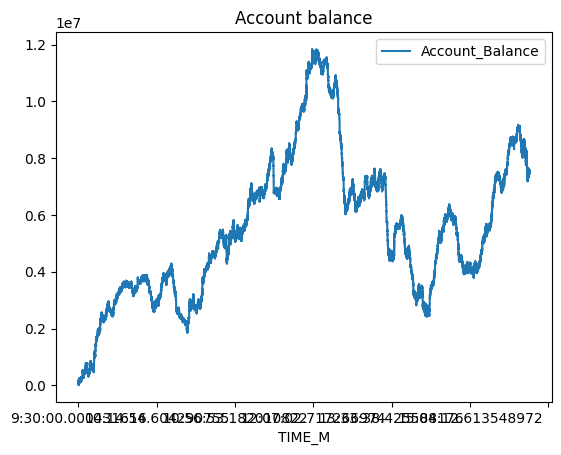

In [25]:
signal_data.plot(x='TIME_M', y='Account_Balance', title='Account balance')

In [26]:
signal_data['Account_Balance'].describe()

count    1.151755e+07
mean     5.504565e+06
std      2.589478e+06
min      1.315400e+04
25%      3.505158e+06
50%      5.292896e+06
75%      7.115278e+06
max      1.185211e+07
Name: Account_Balance, dtype: float64

In [1]:
signal_data.tail()

NameError: name 'signal_data' is not defined

In [30]:
signal_data.to_csv('./data/obi_strategy_results.csv', index=False)

In [3]:
signal_data = pd.read_csv('./data/obi_strategy_results.csv')

In [4]:
signal_data

,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,...,best_bid,best_ask,total_best_bid_size,total_best_ask_size,MID_PRICE,Volume,VWAP,OBI,Signal,Account_Balance
0,2023-05-10,9:30:00.000431616,Q,172.98,2,173.02,34,R,1095038,4,...,172.98,173.02,2,34,173.000,36,NaN,-0.888889,-1,99998.0
1,2023-05-10,9:30:00.000735136,U,172.92,1,173.04,1,R,1095065,0,...,172.98,173.02,2,34,173.000,36,NaN,-0.888889,-1,99998.0
2,2023-05-10,9:30:00.000890000,P,172.94,11,173.09,3,R,1095078,0,...,172.98,173.02,2,34,173.000,36,NaN,-0.888889,-1,99998.0
3,2023-05-10,9:30:00.000916688,Q,172.98,3,173.02,34,R,1095080,4,...,172.98,173.02,3,34,173.000,37,NaN,-0.837838,-1,99998.0
4,2023-05-10,9:30:00.000934507,P,172.94,11,173.04,1,R,1095083,0,...,172.98,173.02,3,34,173.000,37,NaN,-0.837838,-1,99998.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11517545,2023-05-10,15:59:59.996241530,V,139.00,2,175.00,4,R,83998329,0,...,173.55,173.56,58,42,173.555,100,173.552494,0.160000,1,7580979.5
11517546,2023-05-10,15:59:59.996299423,K,173.55,1,173.58,2,R,83998331,0,...,173.55,173.56,59,42,173.555,101,173.552639,0.168317,1,7580979.5
11517547,2023-05-10,15:59:59.996663139,M,173.35,4,173.56,4,R,83998337,0,...,173.55,173.56,59,46,173.555,105,173.552789,0.123810,1,7580979.5
11517548,2023-05-10,15:59:59.996674478,M,173.35,4,173.68,3,R,83998339,0,...,173.55,173.56,59,46,173.555,105,173.552940,0.123810,1,7580979.5


In [6]:
signal_data['OBI'].sum()

13132.87347555566